In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/raw/insurance.csv")

print("Dataset loaded successfully")
print("Shape:", df.shape)

Dataset loaded successfully
Shape: (1338, 7)


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
print(df.dtypes)

Column names:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

Data types:
age           int64
sex             str
bmi         float64
children      int64
smoker          str
region          str
charges     float64
dtype: object


In [4]:
print("Null counts:")
print(df.isna().sum())

print("\nUnique-value counts:")
print(df.nunique())

Null counts:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Unique-value counts:
age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64


## Dataset Selection

**Dataset:** Medical Cost Personal Dataset

**Source:** Kaggle — Medical Cost Personal Datasets  
https://www.kaggle.com/datasets/mirichoi0218/insurance

**License:** Public domain / Open Database, Contents: Database Contents

I chose this dataset because it contains more than 200 observations and includes both numeric and categorical variables. It is suitable for exploring how factors such as age, smoking status, BMI, and region relate to medical insurance charges, while also providing useful opportunities for GroupBy aggregation, merging, reshaping, NumPy-based computation, and visualization.

In [5]:
duplicate_count = df.duplicated().sum()

print("Duplicate rows:", duplicate_count)

Duplicate rows: 1


In [6]:

df = df.drop_duplicates().reset_index(drop=True)

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (1337, 7)


In [7]:
print("Missing values after cleaning:")
print(df.isna().sum())

print("\nDuplicate rows after cleaning:", df.duplicated().sum())

Missing values after cleaning:
age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Duplicate rows after cleaning: 0


## Data Cleaning Decisions

The dataset contained no missing values, so no imputation or deletion for missing data was necessary. One exact duplicate row was found and removed because it did not provide additional information. The remaining columns already had appropriate data types for the planned analysis, so no unnecessary dtype conversions were applied.

In [8]:
# Grouping by smoking status shows the typical insurance charges for smokers and non-smokers.
print("Shape before GroupBy:", df.shape)

smoker_stats = (
    df.groupby("smoker")["charges"]
    .agg(["mean", "median"])
    .reset_index()
)

print("\nGrouped statistics:")
print(smoker_stats)

Shape before GroupBy: (1337, 7)

Grouped statistics:
  smoker          mean       median
0     no   8440.660307   7345.72660
1    yes  32050.231832  34456.34845


In [9]:
# Merging group statistics back onto each row lets us compare an individual's charge with their smoker group's typical charge.
print("Shape before merge:", df.shape)

df = df.merge(
    smoker_stats,
    on="smoker",
    how="left",
    suffixes=("", "_smoker_group")
)

print("Shape after merge:", df.shape)
print(df.head())

Shape before merge: (1337, 7)
Shape after merge: (1337, 9)
   age     sex     bmi  children smoker     region      charges          mean  \
0   19  female  27.900         0    yes  southwest  16884.92400  32050.231832   
1   18    male  33.770         1     no  southeast   1725.55230   8440.660307   
2   28    male  33.000         3     no  southeast   4449.46200   8440.660307   
3   33    male  22.705         0     no  northwest  21984.47061   8440.660307   
4   32    male  28.880         0     no  northwest   3866.85520   8440.660307   

        median  
0  34456.34845  
1   7345.72660  
2   7345.72660  
3   7345.72660  
4   7345.72660  


In [10]:
df = df.rename(
    columns={
        "mean": "smoker_group_mean_charge",
        "median": "smoker_group_median_charge"
    }
)

print(df.columns.tolist())

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'smoker_group_mean_charge', 'smoker_group_median_charge']


In [11]:
# A pivot table compares average insurance charges across region and smoking status.
print("Shape before pivot:", df.shape)

charge_pivot = pd.pivot_table(
    df,
    values="charges",
    index="region",
    columns="smoker",
    aggfunc="mean"
)

print("\nAverage charges by region and smoking status:")
print(charge_pivot)

print("\nShape after pivot:", charge_pivot.shape)

Shape before pivot: (1337, 9)

Average charges by region and smoking status:
smoker              no           yes
region                              
northeast  9165.531672  29673.536473
northwest  8582.467101  30192.003182
southeast  8032.216309  34844.996824
southwest  8019.284513  32269.063494

Shape after pivot: (4, 2)


In [12]:
print("Final DataFrame shape:", df.shape)
print("\nFirst five rows:")
print(df.head())

Final DataFrame shape: (1337, 9)

First five rows:
   age     sex     bmi  children smoker     region      charges  \
0   19  female  27.900         0    yes  southwest  16884.92400   
1   18    male  33.770         1     no  southeast   1725.55230   
2   28    male  33.000         3     no  southeast   4449.46200   
3   33    male  22.705         0     no  northwest  21984.47061   
4   32    male  28.880         0     no  northwest   3866.85520   

   smoker_group_mean_charge  smoker_group_median_charge  
0              32050.231832                 34456.34845  
1               8440.660307                  7345.72660  
2               8440.660307                  7345.72660  
3               8440.660307                  7345.72660  
4               8440.660307                  7345.72660  


In [13]:
charges_array = df["charges"].to_numpy()

print("Array type:", type(charges_array))
print("Array shape:", charges_array.shape)
print("First five values:", charges_array[:5])

Array type: <class 'numpy.ndarray'>
Array shape: (1337,)
First five values: [16884.924    1725.5523   4449.462   21984.47061  3866.8552 ]


In [14]:
charges_mean = charges_array.mean()
charges_std = charges_array.std()

charges_standardized = (charges_array - charges_mean) / charges_std

print("Mean of standardized charges:", charges_standardized.mean())
print("Standard deviation:", charges_standardized.std())
print("Minimum:", charges_standardized.min())
print("Maximum:", charges_standardized.max())

Mean of standardized charges: -1.00974659532101e-16
Standard deviation: 1.0
Minimum: -1.0042473509293852
Maximum: 4.1708257119553585


In [15]:
df["charges_standardized"] = charges_standardized

print("DataFrame shape after adding the NumPy feature:", df.shape)
print(df[["charges", "charges_standardized"]].head())

DataFrame shape after adding the NumPy feature: (1337, 10)
       charges  charges_standardized
0  16884.92400              0.297857
1   1725.55230             -0.954381
2   4449.46200             -0.729373
3  21984.47061              0.719104
4   3866.85520             -0.777499


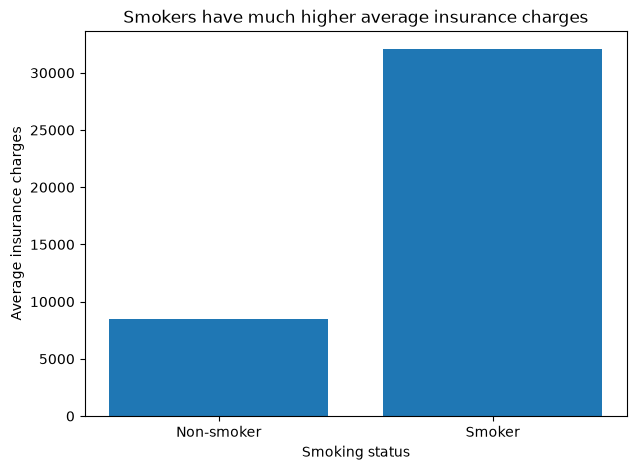

In [30]:
smoker_charges = df.groupby("smoker")["charges"].mean()

plt.figure(figsize=(7, 5))

plt.bar(
    ["Non-smoker", "Smoker"],
    [smoker_charges["no"], smoker_charges["yes"]]
)

plt.xlabel("Smoking status")
plt.ylabel("Average insurance charges")
plt.title("Smokers have much higher average insurance charges")
plt.savefig("../reports/a2_chart1.png", dpi=150, bbox_inches="tight")
plt.show()

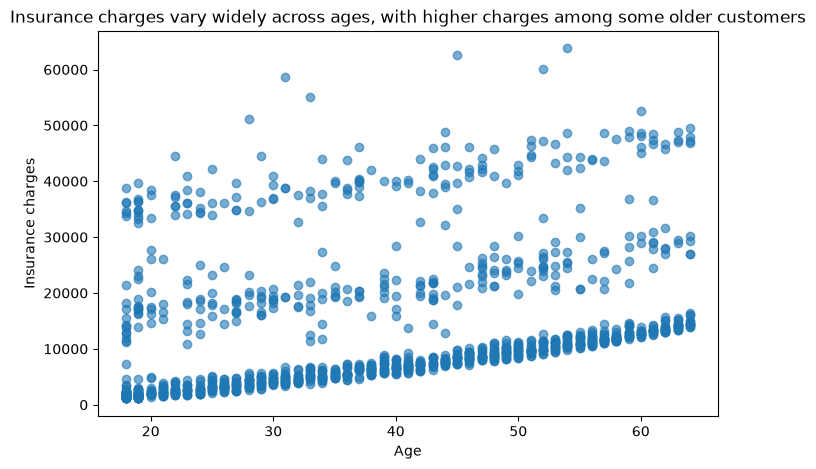

In [31]:
plt.figure(figsize=(8, 5))

plt.scatter(
    df["age"],
    df["charges"],
    alpha=0.6
)

plt.xlabel("Age")
plt.ylabel("Insurance charges")
plt.title("Insurance charges vary widely across ages, with higher charges among some older customers")
plt.savefig("../reports/a2_chart2.png", dpi=150, bbox_inches="tight")
plt.show()

In [32]:
# Save the cleaned and feature-engineered dataset for later use.
df.to_csv("../data/processed/insurance_cleaned.csv", index=False)

print("Cleaned dataset saved successfully.")
print("Shape:", df.shape)

Cleaned dataset saved successfully.
Shape: (1337, 10)


In [33]:
# Check the dataset
print("Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

print("\nFirst 5 rows:")
print(df.head())

print("\nData types:")
print(df.dtypes)

print("\nSummary statistics:")
print(df.describe())

Shape: (1337, 10)

Columns:
['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges', 'smoker_group_mean_charge', 'smoker_group_median_charge', 'charges_standardized']

First 5 rows:
   age     sex     bmi  children smoker     region      charges  \
0   19  female  27.900         0    yes  southwest  16884.92400   
1   18    male  33.770         1     no  southeast   1725.55230   
2   28    male  33.000         3     no  southeast   4449.46200   
3   33    male  22.705         0     no  northwest  21984.47061   
4   32    male  28.880         0     no  northwest   3866.85520   

   smoker_group_mean_charge  smoker_group_median_charge  charges_standardized  
0              32050.231832                 34456.34845              0.297857  
1               8440.660307                  7345.72660             -0.954381  
2               8440.660307                  7345.72660             -0.729373  
3               8440.660307                  7345.72660              0.719104  
4      

In [34]:
# Select features and target
X = df[["age", "bmi"]]
y = df["charges"]

print("Features:")
print(X.head())

print("\nTarget:")
print(y.head())

Features:
   age     bmi
0   19  27.900
1   18  33.770
2   28  33.000
3   33  22.705
4   32  28.880

Target:
0    16884.92400
1     1725.55230
2     4449.46200
3    21984.47061
4     3866.85520
Name: charges, dtype: float64


In [35]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training features:", X_train.shape)
print("Testing features:", X_test.shape)
print("Training target:", y_train.shape)
print("Testing target:", y_test.shape)

Training features: (1069, 2)
Testing features: (268, 2)
Training target: (1069,)
Testing target: (268,)


In [36]:
from sklearn.linear_model import LinearRegression

# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Model trained successfully!")

Model trained successfully!


In [37]:
# Get the model coefficients
print("Intercept:", model.intercept_)

print("Coefficients:")
for feature, coefficient in zip(X.columns, model.coef_):
    print(f"{feature}: {coefficient}")

Intercept: -4460.238126422071
Coefficients:
age: 227.4070270912075
bmi: 280.82349109921864


In [38]:
# Make predictions on the test data
y_pred = model.predict(X_test)

print("First 10 predictions:")
print(y_pred[:10])

First 10 predictions:
[13005.44710315  9323.64703136 17355.28297887 12246.89957231
 13370.1935367  17216.39535218 11067.92091528  7366.7273033
 15326.81326128 14739.53216068]


In [39]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error (MAE):", mae)
print("Root Mean Squared Error (RMSE):", rmse)
print("R-squared (R²):", r2)

Mean Absolute Error (MAE): 9575.763317031431
Root Mean Squared Error (RMSE): 12559.717292569929
R-squared (R²): 0.14154398499742504


In [40]:
comparison = pd.DataFrame({
    "Actual Charges": y_test.values,
    "Predicted Charges": y_pred
})

print(comparison.head(10))

   Actual Charges  Predicted Charges
0      8688.85885       13005.447103
1      5708.86700        9323.647031
2     11436.73815       17355.282979
3     38746.35510       12246.899572
4      4463.20510       13370.193537
5      9304.70190       17216.395352
6     38511.62830       11067.920915
7      2150.46900        7366.727303
8      7345.72660       15326.813261
9     10264.44210       14739.532161


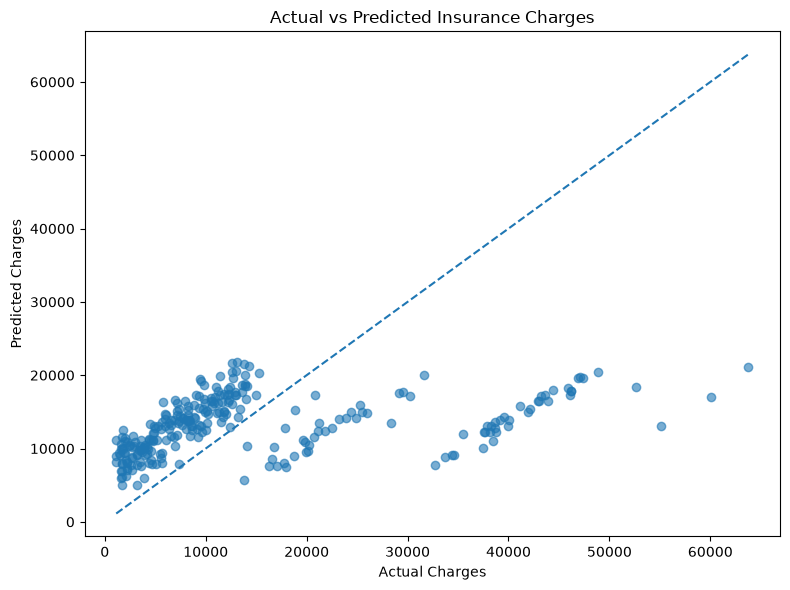

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred, alpha=0.6)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Insurance Charges")

plt.tight_layout()
plt.savefig("../reports/a3_chart1.png")
plt.show()

In [42]:
from sklearn.ensemble import RandomForestRegressor

# Create the Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train the model
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully!")

Random Forest model trained successfully!


In [43]:
# Make predictions with the Random Forest model
rf_pred = rf_model.predict(X_test)

print("First 10 Random Forest predictions:")
print(rf_pred[:10])

First 10 Random Forest predictions:
[11064.2327772  6578.833981  11895.1527548 18558.8273949 34753.6438833
 12655.5888258 14276.6472672  8553.1533036 23469.7364459  9273.1792305]


In [44]:
# Calculate Random Forest evaluation metrics
rf_mae = mean_absolute_error(y_test, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_pred))
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest Mean Absolute Error (MAE):", rf_mae)
print("Random Forest Root Mean Squared Error (RMSE):", rf_rmse)
print("Random Forest R-squared (R²):", rf_r2)

Random Forest Mean Absolute Error (MAE): 10048.559945083856
Random Forest Root Mean Squared Error (RMSE): 14016.624589929925
Random Forest R-squared (R²): -0.06916615742861243


## Model Comparison and Conclusion

I built and evaluated two regression models to predict insurance charges using **age** and **BMI** as the features: Linear Regression and Random Forest Regression.

The **Linear Regression model performed better** than the Random Forest model on the test data. Linear Regression had an MAE of **$9,575.76**, an RMSE of **$12,559.72**, and an R² of **0.1415**. In comparison, the Random Forest model had a higher MAE of **$10,048.56**, a higher RMSE of **$14,016.62**, and a negative R² of **-0.0692**.

Therefore, **Linear Regression predicts the insurance charges more accurately in this experiment**, because it has lower prediction errors and a higher R² score. I would trust the Linear Regression model more for this dataset and these features.

However, both models have limited predictive power because only **age and BMI** were used to predict insurance charges. Other variables in the dataset, such as smoking status, may have a strong influence on charges. Including more relevant features could improve the performance of both models.
